## Data Generation 

In [10]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import uuid

In [11]:
# Constants
MAX_DAYS = 365  # For DaysSinceLastPurchase for cold SKUs
ROLLING_WINDOW_WEEKS = 4  # X weeks for rolling features
NEGATIVE_SAMPLING_RATIO = 5  # Negative to positive sample ratio
NUM_WEEKS = 10  # Number of historical weeks for training
INFERENCE_WEEK = 11  # Week for inference

In [12]:
# Generate synthetic data for demonstration
def generate_synthetic_data():
    # SKU Metadata
    skus = pd.DataFrame({
        'SKUID': [f'SKU{i}' for i in range(1, 101)],
        'Manufacturer': np.random.choice(['M1', 'M2', 'M3'], 100),
        'Category': np.random.choice(['Cat1', 'Cat2', 'Cat3'], 100),
        'Segment': np.random.choice(['Seg1', 'Seg2'], 100)
    })
    
    # Customer Metadata
    customers = pd.DataFrame({
        'CustomerID': [f'C{i}' for i in range(1, 51)],
        'State': np.random.choice(['State1', 'State2'], 50),
        'City': np.random.choice(['City1', 'City2'], 50),
        'Town': np.random.choice(['Town1', 'Town2'], 50),
        'Recency': np.random.randint(1, 100, 50),
        'Frequency': np.random.randint(1, 50, 50),
        'Monetary': np.random.uniform(100, 10000, 50)
    })
    
    # Transaction Records (random purchases)
    transactions = []
    start_date = datetime(2025, 1, 1)
    for week in range(1, NUM_WEEKS + 1):
        week_date = start_date + timedelta(weeks=week - 1)
        for _ in range(200):  # 200 transactions per week
            customer = np.random.choice(customers['CustomerID'])
            sku = np.random.choice(skus['SKUID'])
            transactions.append({
                'Week': week,
                'CustomerID': customer,
                'SKUID': sku,
                'OrderValue': np.random.uniform(10, 500),
                'TransactionDate': week_date
            })
    transactions = pd.DataFrame(transactions)
    
    return skus, customers, transactions


In [13]:
# Feature engineering function
def compute_features(week, transactions, skus, customers, is_inference=False):
    # Filter transactions up to the previous week to avoid leakage
    if is_inference:
        hist_transactions = transactions[transactions['Week'] <= week - 1]
    else:
        hist_transactions = transactions[transactions['Week'] < week]
    
    features_list = []
    
    # For each (Week, CustomerID, SKUID) pair
    for _, row in transactions[transactions['Week'] == week].iterrows() if not is_inference else transactions.iterrows():
        customer_id = row['CustomerID'] if not is_inference else row['CustomerID']
        sku_id = row['SKUID'] if not is_inference else row['SKUID']
        feature_dict = {'Week': week, 'CustomerID': customer_id, 'SKUID': sku_id}
        
        # Join with SKU and Customer metadata
        sku_info = skus[skus['SKUID'] == sku_id].iloc[0] if sku_id in skus['SKUID'].values else None
        customer_info = customers[customers['CustomerID'] == customer_id].iloc[0]
        
        if sku_info is None:
            continue  # Skip if SKU not found
        
        # Customer-SKU Interaction Features
        customer_sku_transactions = hist_transactions[
            (hist_transactions['CustomerID'] == customer_id) & 
            (hist_transactions['SKUID'] == sku_id)
        ]
        feature_dict['DaysSinceLastPurchase_SKU'] = (
            MAX_DAYS + 1 if customer_sku_transactions.empty 
            else (datetime(2025, 1, 1) + timedelta(weeks=week - 1) - 
                  customer_sku_transactions['TransactionDate'].max()).days
        )
        feature_dict['TotalPurchases_SKU'] = len(customer_sku_transactions)
        feature_dict['AvgOrderValue_SKU_by_Customer'] = (
            customer_sku_transactions['OrderValue'].mean() if not customer_sku_transactions.empty else 0
        )
        
        # Customer General Behavior (RFM)
        feature_dict['Customer_Recency'] = customer_info['Recency']
        feature_dict['Customer_Frequency'] = customer_info['Frequency']
        feature_dict['Customer_Monetary'] = customer_info['Monetary']
        feature_dict['Customer_TotalUniqueSKUsPurchased_Overall'] = len(
            hist_transactions[hist_transactions['CustomerID'] == customer_id]['SKUID'].unique()
        )
        
        # Localized SKU Performance (State)
        state = customer_info['State']
        state_transactions = hist_transactions[hist_transactions['CustomerID'].isin(
            customers[customers['State'] == state]['CustomerID']
        )]
        feature_dict['SKU_TotalSales_CustomerState_Overall'] = state_transactions[
            state_transactions['SKUID'] == sku_id
        ]['OrderValue'].sum()
        
        # Time-Series & Rolling Window (X-Weeks)
        rolling_transactions = hist_transactions[
            (hist_transactions['Week'] >= week - ROLLING_WINDOW_WEEKS) & 
            (hist_transactions['Week'] <= week - 1)
        ]
        customer_rolling = rolling_transactions[rolling_transactions['CustomerID'] == customer_id]
        feature_dict['Customer_RollingAvgOrderValue_XWeeks'] = (
            customer_rolling['OrderValue'].mean() if not customer_rolling.empty else 0
        )
        feature_dict['Customer_RollingUniqueSKUsPurchased_XWeeks'] = len(customer_rolling['SKUID'].unique())
        
        # Granular Location Affinity (Town)
        town = customer_info['Town']
        town_transactions = hist_transactions[hist_transactions['CustomerID'].isin(
            customers[customers['Town'] == town]['CustomerID']
        )]
        feature_dict['Town_SKU_PurchaseCount_XWeeks'] = len(
            town_transactions[town_transactions['SKUID'] == sku_id]
        )
        
        features_list.append(feature_dict)
    
    return pd.DataFrame(features_list)


In [14]:
# Generate training data week on week
def generate_training_data(skus, customers, transactions):
    # skus, customers, transactions = generate_synthetic_data()
    all_training_data = []
    
    for week in range(1, NUM_WEEKS + 1):
        # Positive samples (purchases in this week)
        week_transactions = transactions[transactions['Week'] == week][['Week', 'CustomerID', 'SKUID']].copy()
        week_transactions['purchase_likelihood'] = 1
        
        # Negative samples
        negative_samples = []
        for customer_id in week_transactions['CustomerID'].unique():
            purchased_skus = week_transactions[week_transactions['CustomerID'] == customer_id]['SKUID'].unique()
            non_purchased_skus = skus[~skus['SKUID'].isin(purchased_skus)]['SKUID'].sample(
                n=len(purchased_skus) * NEGATIVE_SAMPLING_RATIO
            )
            for sku_id in non_purchased_skus:
                negative_samples.append({
                    'Week': week,
                    'CustomerID': customer_id,
                    'SKUID': sku_id,
                    'purchase_likelihood': 0
                })
        
        week_data = pd.concat([
            week_transactions,
            pd.DataFrame(negative_samples)
        ], ignore_index=True)
        
        # Compute features
        week_features = compute_features(week, transactions, skus, customers)
        week_data = week_data.merge(week_features, on=['Week', 'CustomerID', 'SKUID'], how='left')
        
        all_training_data.append(week_data)
    
    return pd.concat(all_training_data, ignore_index=True)


In [15]:
# Generate inference data for a single week
def generate_inference_data(skus, customers, transactions):
    # skus, customers, transactions = generate_synthetic_data()
    
    # Curate SKUs for each customer
    inference_samples = []
    for customer_id in customers['CustomerID']:
        # Previously purchased SKUs
        purchased_skus = transactions[transactions['CustomerID'] == customer_id]['SKUID'].unique()
        
        # Popular SKUs (top 5 by total sales in customer's state)
        customer_state = customers[customers['CustomerID'] == customer_id]['State'].iloc[0]
        state_customers = customers[customers['State'] == customer_state]['CustomerID']
        state_transactions = transactions[transactions['CustomerID'].isin(state_customers)]
        popular_skus = state_transactions.groupby('SKUID')['OrderValue'].sum().nlargest(5).index
        
        # Category-relevant SKUs (top 5 from customer's frequent categories)
        customer_categories = transactions[transactions['CustomerID'] == customer_id].merge(
            skus, on='SKUID'
        )['Category'].value_counts().index[:2]
        category_skus = skus[skus['Category'].isin(customer_categories)]['SKUID'].sample(5, replace=True)
        
        # Combine curated SKUs (remove duplicates)
        curated_skus = list(set(list(purchased_skus) + list(popular_skus) + list(category_skus)))
        
        for sku_id in curated_skus[:50]:  # Limit to 50 SKUs per customer
            inference_samples.append({
                'Week': INFERENCE_WEEK,
                'CustomerID': customer_id,
                'SKUID': sku_id
            })
    
    inference_data = pd.DataFrame(inference_samples)
    
    # Compute features
    inference_features = compute_features(INFERENCE_WEEK, transactions, skus, customers, is_inference=True)
    inference_data = inference_data.merge(inference_features, on=['Week', 'CustomerID', 'SKUID'], how='left')
    
    return inference_data


In [ ]:
# Run the data generation
if __name__ == "__main__":
    skus, customers, transactions = generate_synthetic_data()
    # Generate and save training data
    training_data = generate_training_data(skus, customers, transactions)
    training_data.to_csv('training_data.csv', index=False)
    print("Training data generated and saved to 'training_data.csv'")
    
    # Generate and save inference data
    inference_data = generate_inference_data(skus, customers, transactions)
    inference_data.to_csv('inference_data.csv', index=False)
    print("Inference data generated and saved to 'inference_data.csv'")

In [16]:
skus, customers, transactions = generate_synthetic_data()

In [20]:
from plotnine import *
import pandas as pd

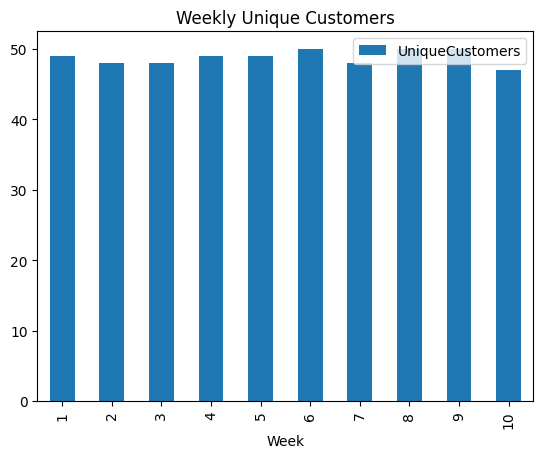

In [23]:
import matplotlib.pyplot as plt
# Bar plot of unique customer per week
transactions.groupby('Week').agg({'CustomerID': 'nunique'}).reset_index().rename(columns={'CustomerID': 'UniqueCustomers'})\
    .plot(kind='bar', x='Week', y='UniqueCustomers', title='Weekly Unique Customers')
plt.show()
# transactions.groupby('Week').agg({'CustomerID': 'count'}).reset_index().rename(columns={'OrderValue': 'TotalSales'}) .plot(kind='bar', x='Week', y='TotalSales', title='Weekly Transactions Count')
# plt.show()

In [27]:

# # Create a plot
# plot = (
#     ggplot(transactions.groupby('Week').agg({'CustomerID': 'nunique'}).reset_index().rename(columns={'CustomerID': 'UniqueCustomers'}), 
#            aes(x='Week', y='UniqueCustomers')) +
#     geom_col() +
#     # geom_smooth(method='lm', color='blue') +
#     # ggtitle("Sample Plot using Plotnine") +
#     xlab("Week") +
#     ylab("Uniq. Customers")  
# )

# # Display the plot
# # print(plot)
# plot


In [ ]:
pri

,Week,CustomerID,SKUID,OrderValue,TransactionDate
0,1,C36,SKU53,389.393095,2025-01-01
1,1,C8,SKU66,411.230520,2025-01-01
2,1,C46,SKU24,438.871003,2025-01-01
3,1,C4,SKU7,404.880044,2025-01-01
4,1,C2,SKU70,263.494909,2025-01-01
5,1,C44,SKU59,365.882951,2025-01-01
6,1,C32,SKU35,434.807833,2025-01-01
7,1,C14,SKU20,81.740179,2025-01-01
8,1,C20,SKU71,360.733110,2025-01-01
9,1,C42,SKU95,490.210756,2025-01-01


In [33]:
skus, customers, transactions = generate_synthetic_data()
# Generate and save training data
training_data = generate_training_data(skus, customers, transactions)
training_data.to_csv('training_data.csv', index=False)
print("Training data generated and saved to 'training_data.csv'")

# Generate and save inference data
inference_data = generate_inference_data(skus, customers, transactions)
inference_data.to_csv('inference_data.csv', index=False)
print("Inference data generated and saved to 'inference_data.csv'")

Training data generated and saved to 'training_data.csv'
Inference data generated and saved to 'inference_data.csv'


In [42]:
print(training_data.Week.nunique())

print(inference_data.Week.nunique())

10
1


In [45]:
print(training_data.drop('purchase_likelihood', axis=1).columns.tolist())

print(inference_data.columns.tolist())

['Week', 'CustomerID', 'SKUID', 'DaysSinceLastPurchase_SKU', 'TotalPurchases_SKU', 'AvgOrderValue_SKU_by_Customer', 'Customer_Recency', 'Customer_Frequency', 'Customer_Monetary', 'Customer_TotalUniqueSKUsPurchased_Overall', 'SKU_TotalSales_CustomerState_Overall', 'Customer_RollingAvgOrderValue_XWeeks', 'Customer_RollingUniqueSKUsPurchased_XWeeks', 'Town_SKU_PurchaseCount_XWeeks']
['Week', 'CustomerID', 'SKUID', 'DaysSinceLastPurchase_SKU', 'TotalPurchases_SKU', 'AvgOrderValue_SKU_by_Customer', 'Customer_Recency', 'Customer_Frequency', 'Customer_Monetary', 'Customer_TotalUniqueSKUsPurchased_Overall', 'SKU_TotalSales_CustomerState_Overall', 'Customer_RollingAvgOrderValue_XWeeks', 'Customer_RollingUniqueSKUsPurchased_XWeeks', 'Town_SKU_PurchaseCount_XWeeks']
